In [476]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle
import pathlib

sns.set_style("whitegrid")
sns.set_context("paper")
sns.set_palette("deep", color_codes=True)


In [477]:
results_folder = "qaoa_results_9_warm_start_at_2"
result_files = {path.as_posix().split("/")[-1].split(".")[0]: {"path": path} for path in list(pathlib.Path(f"qaoa/{results_folder}").glob("*.npz"))}
result_files

{'5PTI_18_22_5_6_layers': {'path': PosixPath('qaoa/qaoa_results_9_warm_start_at_2/5PTI_18_22_5_6_layers.npz')},
 '5PTI_22_28_4_8_layers': {'path': PosixPath('qaoa/qaoa_results_9_warm_start_at_2/5PTI_22_28_4_8_layers.npz')},
 '5PTI_22_26_5_8_layers': {'path': PosixPath('qaoa/qaoa_results_9_warm_start_at_2/5PTI_22_26_5_8_layers.npz')},
 '5PTI_21_25_4_8_layers': {'path': PosixPath('qaoa/qaoa_results_9_warm_start_at_2/5PTI_21_25_4_8_layers.npz')},
 '5PTI_18_23_4_6_layers': {'path': PosixPath('qaoa/qaoa_results_9_warm_start_at_2/5PTI_18_23_4_6_layers.npz')},
 '5PTI_20_24_4_8_layers': {'path': PosixPath('qaoa/qaoa_results_9_warm_start_at_2/5PTI_20_24_4_8_layers.npz')},
 '5PTI_22_27_4_8_layers': {'path': PosixPath('qaoa/qaoa_results_9_warm_start_at_2/5PTI_22_27_4_8_layers.npz')},
 '5PTI_19_23_5_6_layers': {'path': PosixPath('qaoa/qaoa_results_9_warm_start_at_2/5PTI_19_23_5_6_layers.npz')},
 '5PTI_22_27_4_12_layers': {'path': PosixPath('qaoa/qaoa_results_9_warm_start_at_2/5PTI_22_27_4_12_layer

In [479]:
data_keys = ["cost_history", "target_probs", "target_indices", "best_target_index", "conformation_map"]
names_set = set()

for name, data in result_files.items():
    with open(data["path"], 'rb') as f:
        saved_results = np.load(f, allow_pickle=True)
        result_files[name]["data"] = {key: saved_results[key] for key in data_keys}

    result_files[name]["protein"] = name.split("_")[0]
    result_files[name]["start_residue"] = int(name.split("_")[1])
    result_files[name]["end_residue"] = int(name.split("_")[2])
    result_files[name]["rotamer_count"] = int(name.split("_")[3])
    result_files[name]["qaoa_layers"] = int(name.split("_")[4])

    result_files[name]["subsection"] = f"{result_files[name]['start_residue']}-{result_files[name]['end_residue']}"
    result_files[name]["subsection_length"] = result_files[name]["end_residue"] - result_files[name]["start_residue"] + 1

    name_without_layers = "_".join(name.split("_")[:-2])
    names_set.add(name_without_layers)

In [480]:
names_set

{'5PTI_18_22_4',
 '5PTI_18_22_5',
 '5PTI_18_23_4',
 '5PTI_19_23_4',
 '5PTI_19_23_5',
 '5PTI_20_24_4',
 '5PTI_20_25_4',
 '5PTI_21_25_4',
 '5PTI_21_25_5',
 '5PTI_22_26_4',
 '5PTI_22_26_5',
 '5PTI_22_27_4',
 '5PTI_22_27_5',
 '5PTI_22_28_4',
 '5PTI_22_28_5'}

In [496]:
from qaoa.objects import init_basic_params
from qaoa.main import load_qaoa_data

energy_files = list(pathlib.Path("extraction/energies/small").glob("*.pkl"))
file_to_qubit_mapping = {}
for file in energy_files:
    one_body, _ = load_qaoa_data(file)
    basic_params = init_basic_params(one_body)
    file_to_qubit_mapping[file.stem] = basic_params.num_qubits
file_to_qubit_mapping

{'5PTI_22_28_4': 12,
 '5PTI_18_22_4': 11,
 '5PTI_18_22_5': 12,
 '5PTI_22_28_5': 14,
 '5PTI_21_25_5': 14,
 '5PTI_21_25_4': 12,
 '5PTI_20_25_4': 14,
 '5PTI_20_24_4': 14,
 '5PTI_18_23_4': 15,
 '5PTI_19_23_4': 12,
 '5PTI_19_23_5': 13,
 '5PTI_22_27_4': 12,
 '5PTI_22_27_5': 14,
 '5PTI_22_26_4': 12,
 '5PTI_22_26_5': 14}

In [497]:
# Attach number of qubits to each result record
for name, data in result_files.items():
    name_without_layers = "_".join(name.split("_")[:-2])
    if name_without_layers in file_to_qubit_mapping:
        result_files[name]["num_qubits"] = file_to_qubit_mapping[name_without_layers]
    else:
        print(f"Warning: No qubit mapping found for {name_without_layers}. Setting num_qubits to None.")
        result_files[name]["num_qubits"] = None

In [499]:
target_probs_records = []

for name, data in result_files.items():
    # if not name.startswith("5PTI_18_22"): continue

    target_probs = result_files[name]["data"]['target_probs']
    print("Shape of target_probs:", target_probs.shape)  # Should be (30, 16)

    # Sum across the 16 conformations for each seed
    summed_probs = target_probs.sum(axis=1)  # Shape becomes (30,)
    print("Shape after summing across conformations:", summed_probs.shape)

    # Create a record for each seed with its summed probability
    for seed_idx, summed_prob in enumerate(summed_probs):
        record = {
            'protein': result_files[name]['protein'],
            'subsection': result_files[name]['subsection'],
            'subsection_length': result_files[name]['subsection_length'],
            'rotamer_count': result_files[name]['rotamer_count'],
            'qaoa_layers': result_files[name]['qaoa_layers'],
            'num_qubits': result_files[name]['num_qubits'],
            'seed': seed_idx,
            'target_prob': summed_prob  # This is now the sum across all 16 conformations
        }
        target_probs_records.append(record)

# Create dataframe from records
target_probs_df = pd.DataFrame(target_probs_records)

Shape of target_probs: (30, 4)
Shape after summing across conformations: (30,)
Shape of target_probs: (30, 16)
Shape after summing across conformations: (30,)
Shape of target_probs: (30, 17)
Shape after summing across conformations: (30,)
Shape of target_probs: (30, 14)
Shape after summing across conformations: (30,)
Shape of target_probs: (30, 14)
Shape after summing across conformations: (30,)
Shape of target_probs: (30, 18)
Shape after summing across conformations: (30,)
Shape of target_probs: (30, 16)
Shape after summing across conformations: (30,)
Shape of target_probs: (30, 8)
Shape after summing across conformations: (30,)
Shape of target_probs: (30, 16)
Shape after summing across conformations: (30,)
Shape of target_probs: (30, 16)
Shape after summing across conformations: (30,)
Shape of target_probs: (30, 14)
Shape after summing across conformations: (30,)
Shape of target_probs: (30, 4)
Shape after summing across conformations: (30,)
Shape of target_probs: (30, 14)
Shape after

In [500]:
target_probs_df

,protein,subsection,subsection_length,rotamer_count,qaoa_layers,num_qubits,seed,target_prob
0,5PTI,18-22,5,5,6,12,0,0.538523
1,5PTI,18-22,5,5,6,12,1,0.184211
2,5PTI,18-22,5,5,6,12,2,0.010637
3,5PTI,18-22,5,5,6,12,3,0.216253
4,5PTI,18-22,5,5,6,12,4,0.110863
...,...,...,...,...,...,...,...,...
2245,5PTI,22-28,7,4,6,12,25,0.978950
2246,5PTI,22-28,7,4,6,12,26,0.815136
2247,5PTI,22-28,7,4,6,12,27,0.929771
2248,5PTI,22-28,7,4,6,12,28,0.932662


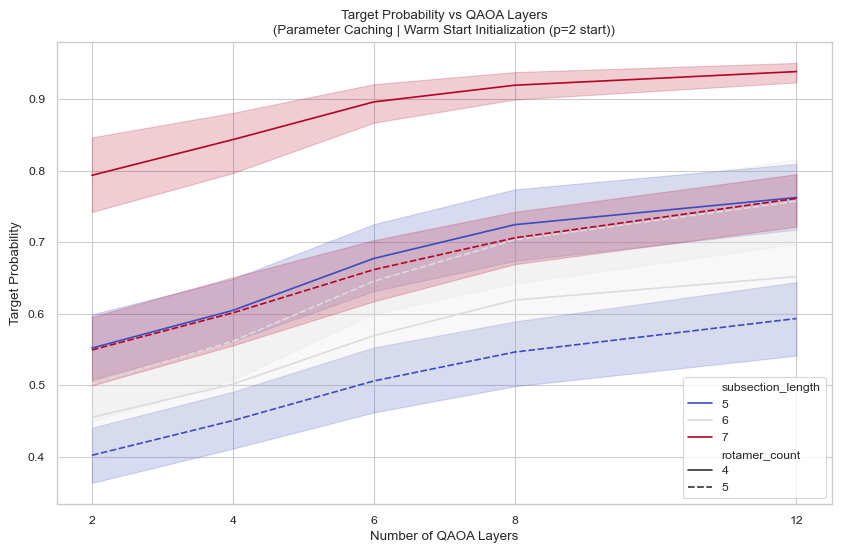

In [501]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data=target_probs_df,
             x="qaoa_layers", y="target_prob",
             hue='subsection_length', style='rotamer_count',
             markers=False,
             palette=sns.color_palette('coolwarm', as_cmap=True, n_colors=target_probs_df['subsection_length'].nunique()),
             ax=ax)

ax.set_xticks([2, 4, 6, 8, 12])

ax.set_title("Target Probability vs QAOA Layers\n(Parameter Caching | Warm Start Initialization (p=2 start))")
ax.set_xlabel("Number of QAOA Layers")
ax.set_ylabel("Target Probability")

plt.savefig(f"plots/{results_folder}_2.svg", dpi=300, bbox_inches='tight')

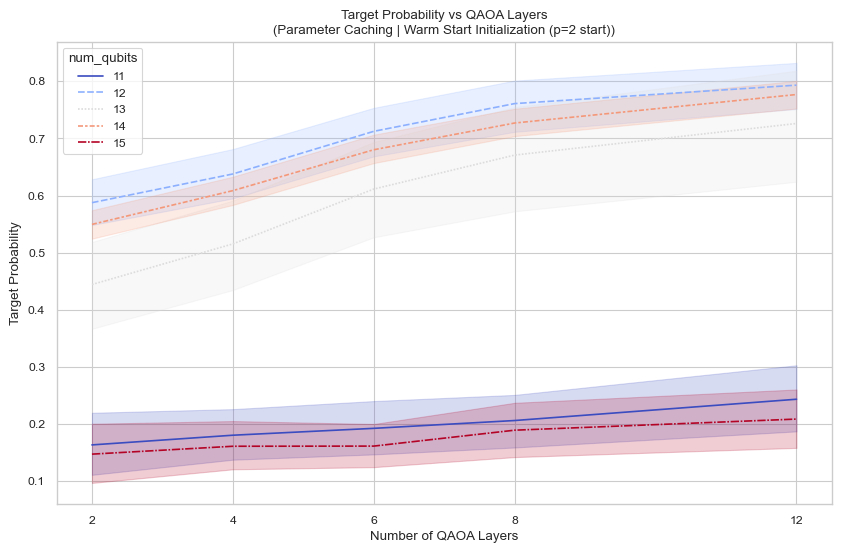

In [502]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data=target_probs_df,
             x="qaoa_layers", y="target_prob",
             hue='num_qubits', style='num_qubits',
             markers=False,
             palette=sns.color_palette('coolwarm', as_cmap=True,
                                       n_colors=target_probs_df['subsection_length'].nunique()),
             ax=ax)

ax.set_xticks([2, 4, 6, 8, 12])

ax.set_title("Target Probability vs QAOA Layers\n(Parameter Caching | Warm Start Initialization (p=2 start))")
ax.set_xlabel("Number of QAOA Layers")
ax.set_ylabel("Target Probability")

plt.savefig(f"plots/{results_folder}_2.svg", dpi=300, bbox_inches='tight')

In [503]:
# Calculate number of shots needed for 99% confidence
target_confidence = 0.9999
target_probs_df['shots_for_99_percent'] = np.ceil(np.log(1 - target_confidence) / np.log(1 - target_probs_df['target_prob']))

# Replace any infinities (when target_prob is very close to 1) with a large number
target_probs_df['shots_for_99_percent'] = target_probs_df['shots_for_99_percent'].replace([np.inf, -np.inf], 1e6)

target_probs_df.head()


,protein,subsection,subsection_length,rotamer_count,qaoa_layers,num_qubits,seed,target_prob,shots_for_99_percent
0,5PTI,18-22,5,5,6,12,0,0.538523,12.0
1,5PTI,18-22,5,5,6,12,1,0.184211,46.0
2,5PTI,18-22,5,5,6,12,2,0.010637,862.0
3,5PTI,18-22,5,5,6,12,3,0.216253,38.0
4,5PTI,18-22,5,5,6,12,4,0.110863,79.0


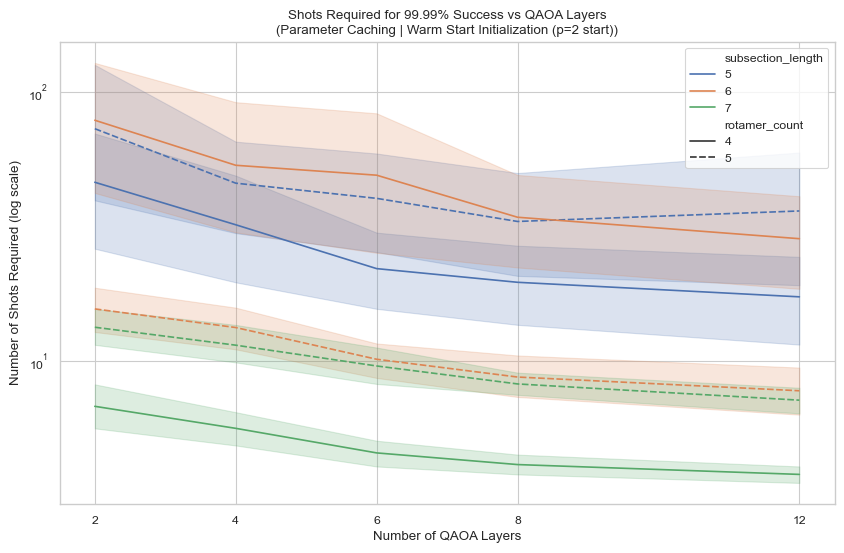

In [504]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data=target_probs_df,
             x="qaoa_layers", y="shots_for_99_percent",
             hue='subsection_length', style='rotamer_count',
             markers=False,
             palette=sns.color_palette('deep', n_colors=target_probs_df['subsection_length'].nunique()),
             ax=ax)

ax.set_xticks([2, 4, 6, 8, 12])
ax.set_yscale('log')  # Use log scale for y-axis since values can span many orders of magnitude

ax.set_title(f"Shots Required for {target_confidence*100:.2f}% Success vs QAOA Layers\n(Parameter Caching | Warm Start Initialization (p=2 start))")
ax.set_xlabel("Number of QAOA Layers")
ax.set_ylabel("Number of Shots Required (log scale)")

plt.savefig(f"plots/{results_folder}_shots.svg", dpi=300, bbox_inches='tight')

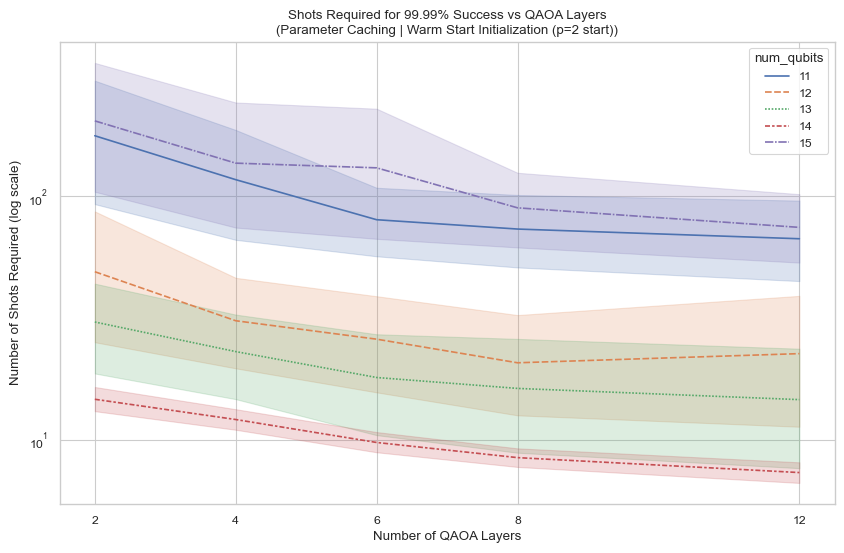

In [506]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data=target_probs_df,
             x="qaoa_layers", y="shots_for_99_percent",
             hue='num_qubits', style='num_qubits',
             markers=False,
             palette=sns.color_palette('deep', n_colors=target_probs_df['num_qubits'].nunique()),
             ax=ax)

ax.set_xticks([2, 4, 6, 8, 12])
ax.set_yscale('log')  # Use log scale for y-axis since values can span many orders of magnitude

ax.set_title(f"Shots Required for {target_confidence*100:.2f}% Success vs QAOA Layers\n(Parameter Caching | Warm Start Initialization (p=2 start))")
ax.set_xlabel("Number of QAOA Layers")
ax.set_ylabel("Number of Shots Required (log scale)")

plt.savefig(f"plots/{results_folder}_shots.svg", dpi=300, bbox_inches='tight')

In [507]:
runtimes = pd.read_pickle("qaoa_runtimes.pkl")
runtimes

,Qubits,Total Layers,Time (s)
0,11,27,904.16
1,11,27,992.14
2,11,32,991.34
3,12,27,1293.50
4,12,27,1308.42
5,12,27,1172.24
6,12,32,1438.87
7,12,32,1273.04
8,12,32,1086.73
9,12,32,1219.43


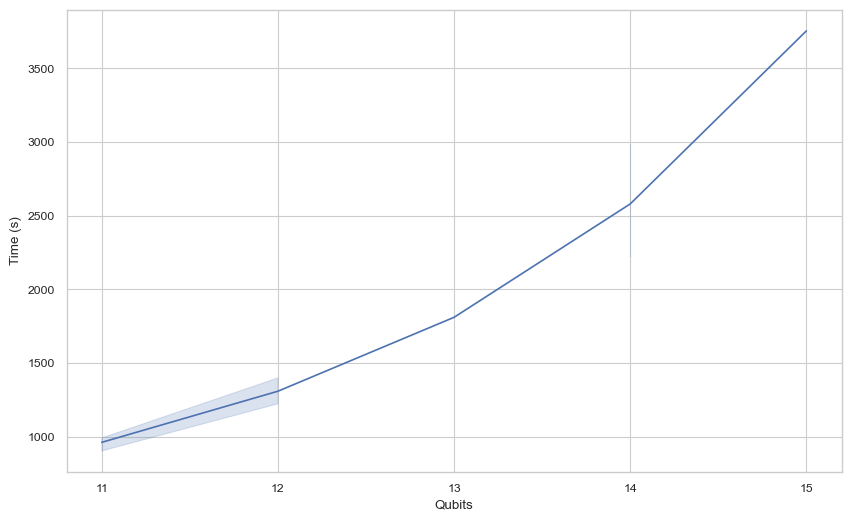

In [517]:
fig, ax = plt.subplots(figsize=(10, 6))

x_axis_vals = runtimes['Qubits'].unique()
x_axis_vals.sort()

sns.lineplot(runtimes, x="Qubits", y="Time (s)",
             markers=False,
             # palette='deep',
             ax=ax)
ax.set_xticks(x_axis_vals)
# ax.set_yscale('log')

plt.savefig(f"plots/runtimes.svg", dpi=300, bbox_inches='tight')